In [1]:
import pandas as pd

main_df = pd.read_csv("owid_climate_data.csv")
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26182 entries, 0 to 26181
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country Name                26182 non-null  str    
 1   Country Code                22895 non-null  str    
 2   Year                        26182 non-null  int64  
 3   CO2 Emissions Per Capita    26182 non-null  float64
 4   Annual Temperature Anomaly  14319 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1022.9 KB


In [2]:
#Step 1 Cleaning the Data Set
#Step 1.5.1 Inspecting if there is any NaN or missing values in the dataset before cleaning.
print("\nMissing values per column:")
print(main_df.isnull().sum()) 
print("\nThe percentage of values missing:")
print(main_df.isnull().mean() * 100)

#12.5% for Country Code missing is fine as it's just an identifier column. Not used for calculations.
#45.3% for Temperature is concerning as it is used for calculations and visualisation.


Missing values per column:
Country Name                      0
Country Code                   3287
Year                              0
CO2 Emissions Per Capita          0
Annual Temperature Anomaly    11863
dtype: int64

The percentage of values missing:
Country Name                   0.000000
Country Code                  12.554427
Year                           0.000000
CO2 Emissions Per Capita       0.000000
Annual Temperature Anomaly    45.309755
dtype: float64


In [3]:
#Step 1.5.2 Checking where atleast 45% of the missing temperature is missing. 
#Which years are missing annual temperature collection
main_df[main_df['Annual Temperature Anomaly'].isna()]['Year'].describe()
print("The mean year of missing values is 1914 — so on average, the missing temperature records are from over 100 years ago. The median (50%) is 1913 — half of all missing values come from before 1913. The 75th percentile is 1949 — meaning 75% of missing temperature values are from before 1949. The max is 2023 — so there are some recent missing values, but they're the exception not the rule.")

The mean year of missing values is 1914 — so on average, the missing temperature records are from over 100 years ago. The median (50%) is 1913 — half of all missing values come from before 1913. The 75th percentile is 1949 — meaning 75% of missing temperature values are from before 1949. The max is 2023 — so there are some recent missing values, but they're the exception not the rule.


In [4]:
#Countries most affected by this loss of data
print(main_df[main_df['Annual Temperature Anomaly'].isna()]['Country Name'].value_counts().head(10)) #Which countries were most affected
print(main_df[main_df['Annual Temperature Anomaly'].isna()]['Country Name'].nunique()) #How many unique countries (not including country duplicates) were affected?

Country Name
Asia                            229
Asia (excl. China and India)    229
Europe                          229
Europe (excl. EU-27)            229
Europe (excl. EU-28)            229
European Union (28)             229
High-income countries           229
Oceania                         229
Taiwan                          229
North America                   225
Name: count, dtype: int64
147


In [5]:
#Step 1.5.3 Cleaning the dataset
cleaned_df = (
    main_df
    .dropna(subset=['Country Code']) #Removes regional aggregates
    .drop(columns=['Country Code']) #Drops Country Code column as it is not needed for our analyses
    .dropna(subset=['Annual Temperature Anomaly']) #Removes missing temperature rows
)
print(f"Rows before cleaning: {len(main_df)}")
print(f"Rows after cleaning: {len(cleaned_df)}")
print(f"Rows removed: {len(main_df) - len(cleaned_df)}")
print(cleaned_df.head())

Rows before cleaning: 26182
Rows after cleaning: 14319
Rows removed: 11863
  Country Name  Year  CO2 Emissions Per Capita  Annual Temperature Anomaly
0  Afghanistan  1949                  0.001992                   -2.020418
1  Afghanistan  1950                  0.010837                   -2.298886
2  Afghanistan  1951                  0.011625                   -1.287201
3  Afghanistan  1952                  0.011468                   -1.237078
4  Afghanistan  1953                  0.013123                   -1.084867


In [6]:
#Step 2 Stesps & Functions
#Step 2.1 
countries_set = set(cleaned_df["Country Name"]) #Automatically removes duplicates
print(countries_set)
print(f"\nTotal unique countries: {len(countries_set)} vs Total countries with duplicates: {len(cleaned_df['Country Name'])}")


{'Albania', 'Bolivia', 'Syria', 'Andorra', 'Serbia', 'Democratic Republic of Congo', 'Yemen', 'World', 'Uganda', 'Anguilla', 'Australia', 'Hong Kong', 'Senegal', 'El Salvador', 'Saint Vincent and the Grenadines', 'Palestine', 'Lebanon', 'Somalia', 'Mongolia', 'Sao Tome and Principe', 'Austria', 'Uruguay', 'Belgium', 'Costa Rica', 'Laos', 'Sudan', 'Thailand', 'Ireland', 'Malawi', 'Gambia', 'Libya', 'New Zealand', 'Zambia', 'Greece', 'Belize', 'United Arab Emirates', 'Eswatini', 'Nicaragua', 'Sri Lanka', 'Tajikistan', 'Qatar', 'Iraq', 'Liberia', 'Angola', 'Bahamas', 'Ecuador', 'Bhutan', 'Botswana', 'Slovenia', 'Turkey', 'China', 'Tunisia', 'Iran', 'Paraguay', 'Myanmar', 'Jordan', 'Antigua and Barbuda', 'Guyana', 'Suriname', 'Zimbabwe', 'Comoros', 'Philippines', 'Solomon Islands', 'Malaysia', 'Cuba', 'Gabon', 'Eritrea', 'Norway', 'Algeria', 'Mauritania', 'Montenegro', 'Trinidad and Tobago', 'Israel', 'Samoa', 'Slovakia', 'Cameroon', 'Canada', 'Lithuania', 'Central African Republic', 'Nami

In [7]:
#Step 2.2 Function to retrieve rows by country and year range
def get_country_data(df, country, start_year, end_year):
    """
    Returns a filtered DataFrame for a given country and year range.

    Parameters: 
    df: any Dataframe
    country: Country name as str
    start_year: Start of year range (inclusive, int)
    end_year: End of year range (inclusive, int)
    """
    if country not in countries_set: #Validates if country exists before filtering
        print(f"'{country}' is not found in the dataset. Please check spelling or print out countries_set to check unique countries.")
        return None 
        
    filtered_country_df = df[
        (df['Country Name'] == country) &
        (df['Year'] >= start_year) &
        (df['Year'] <= end_year)
        ]
    return filtered_country_df.reset_index(drop=True)
    
#Step 2.3 Testing function
north_korea_data = get_country_data(cleaned_df, 'North Korea', 2020, 2020)
print(north_korea_data)

  Country Name  Year  CO2 Emissions Per Capita  Annual Temperature Anomaly
0  North Korea  2020                  2.507916                    0.742774


In [8]:
#Step 3 Logical Filtering
#Step 3.1 Global average of CO2 emissions in 2020
global_avg_co2_2020 = cleaned_df[cleaned_df['Year'] == 2020]['CO2 Emissions Per Capita'].mean()
print(f"Global average CO2 emissions per capita in 2020: {global_avg_co2_2020:.2f} metric tonnes")

Global average CO2 emissions per capita in 2020: 4.34 metric tonnes


In [9]:
#Step 3.2 Filtering countries where CO2 emissions are above 10 metric tons in 2020 
countries_co2_above_10_2020 = cleaned_df[
    (cleaned_df['Year'] == 2020) &
    (cleaned_df['CO2 Emissions Per Capita'] > 10)
    ].reset_index(drop=True).sort_values('CO2 Emissions Per Capita', ascending=False) #From highest emitters to lowest
print(countries_co2_above_10_2020)


            Country Name  Year  CO2 Emissions Per Capita  \
11                 Qatar  2020                 36.564110   
1                Bahrain  2020                 25.215979   
2                 Brunei  2020                 24.939121   
15   Trinidad and Tobago  2020                 23.677786   
16  United Arab Emirates  2020                 23.006842   
6                 Kuwait  2020                 21.739220   
13          Saudi Arabia  2020                 19.879406   
9          New Caledonia  2020                 17.981370   
0              Australia  2020                 15.506062   
10                  Oman  2020                 15.174401   
4          Faroe Islands  2020                 14.426020   
17         United States  2020                 13.889589   
3                 Canada  2020                 13.795024   
5             Kazakhstan  2020                 13.113933   
7             Luxembourg  2020                 12.806264   
14           South Korea  2020          

In [10]:
#Step 4 Probability & Statistics
#1.5 degrees celsius was chosen due to Paris Agreement
paris_threshold = 1.5

#Step 4.1 The % of the recorded observations exceed this threshold
exceeding = cleaned_df[cleaned_df['Annual Temperature Anomaly'] > paris_threshold]
probability = (len(exceeding)) / (len(cleaned_df)) * 100

print(f"Rows exceeding 1.5 degrees: {len(exceeding)}")
print(f"Total rows in dataset: {len(cleaned_df)}")
print(f"Probability of temperature anomaly exceeding {paris_threshold}°C: {probability:.2f}%")

Rows exceeding 1.5 degrees: 49
Total rows in dataset: 14319
Probability of temperature anomaly exceeding 1.5°C: 0.34%


In [11]:
#Step 4.2 Calculating the mean, min, and max of temperature each year
aggregated_temp_per_year = (
    cleaned_df.groupby(['Year'])['Annual Temperature Anomaly'].agg(["mean", "min", "max"]))
print(aggregated_temp_per_year)

          mean       min       max
Year                              
1940 -1.624415 -3.825056  0.423903
1941 -1.251653 -3.941369  1.779448
1942 -1.368997 -3.628582  0.683115
1943 -1.021218 -2.985201  1.080043
1944 -1.000902 -2.997106  0.915558
...        ...       ...       ...
2019  0.601391 -0.226331  1.697816
2020  0.580830 -0.231912  2.247584
2021  0.411804 -0.655329  1.511456
2022  0.444629 -0.582847  1.773571
2023  0.862665 -0.266950  1.894608

[84 rows x 3 columns]


In [12]:
#Step 4.3 Calculating the change in mean temperature anomaly from 1940 to 2023
mean_1940 = aggregated_temp_per_year.loc[1940, 'mean']
mean_2023 = aggregated_temp_per_year.loc[2023, 'mean']
change = mean_2023 - mean_1940

print(f"Mean temperature anomaly in 1940: {mean_1940:.2f}°C")
print(f"Mean temperature anomaly in 2023: {mean_2023:.2f}°C")
print(f"Change in mean temperature anomaly: {change:.2f}°C")

Mean temperature anomaly in 1940: -1.62°C
Mean temperature anomaly in 2023: 0.86°C
Change in mean temperature anomaly: 2.49°C


In [13]:
#Step 5 Counting Principles
#Step 5.1 Individual counts of unique countries & years
print("Unique countries:", cleaned_df["Country Name"].nunique())
print("Unique years:", cleaned_df["Year"].nunique())

Unique countries: 187
Unique years: 84


In [14]:
#Step 5.2 Theoretical maximum combinations
combos = cleaned_df.groupby(['Country Name', 'Year']).size()
print(f"Number of unique country-year combinations: {len(combos)}")

Number of unique country-year combinations: 14319


In [15]:
# Step 5.3 Theoretical maximum vs actual coverage
theoretical_max = cleaned_df["Country Name"].nunique() * cleaned_df["Year"].nunique()
print(f"Theoretical maximum combinations: {theoretical_max}")
print(f"Coverage gap: {theoretical_max - len(combos)} missing combinations")
print(f"Dataset coverage: {(len(combos) / theoretical_max) * 100:.2f}%")

Theoretical maximum combinations: 15708
Coverage gap: 1389 missing combinations
Dataset coverage: 91.16%


In [16]:
#Step 6: Graph Theory & Networks
#Step 6.1 Importing networkx and matplotlib.pyplot
import matplotlib.pyplot as plt
import networkx as nx

#Step 6.2 Building the network graph using the high emitters from Step 3
G = nx.Graph()
for _, row in countries_co2_above_10_2020.iterrows(): #Adding each high emitter as a node
    G.add_node(row['Country Name'],
               co2=row['CO2 Emissions Per Capita']) 

for i, row_i in countries_co2_above_10_2020.iterrows(): # Draw edges between countries if CO2 emissions differ by less than 1.0 metric tonne
    for j, row_j in countries_co2_above_10_2020.iterrows():
        if i < j:  # Avoid duplicate edges and self-loops
            if abs(row_i['CO2 Emissions Per Capita'] - row_j['CO2 Emissions Per Capita']) < 1.0:
                G.add_edge(row_i['Country Name'], row_j['Country Name'])

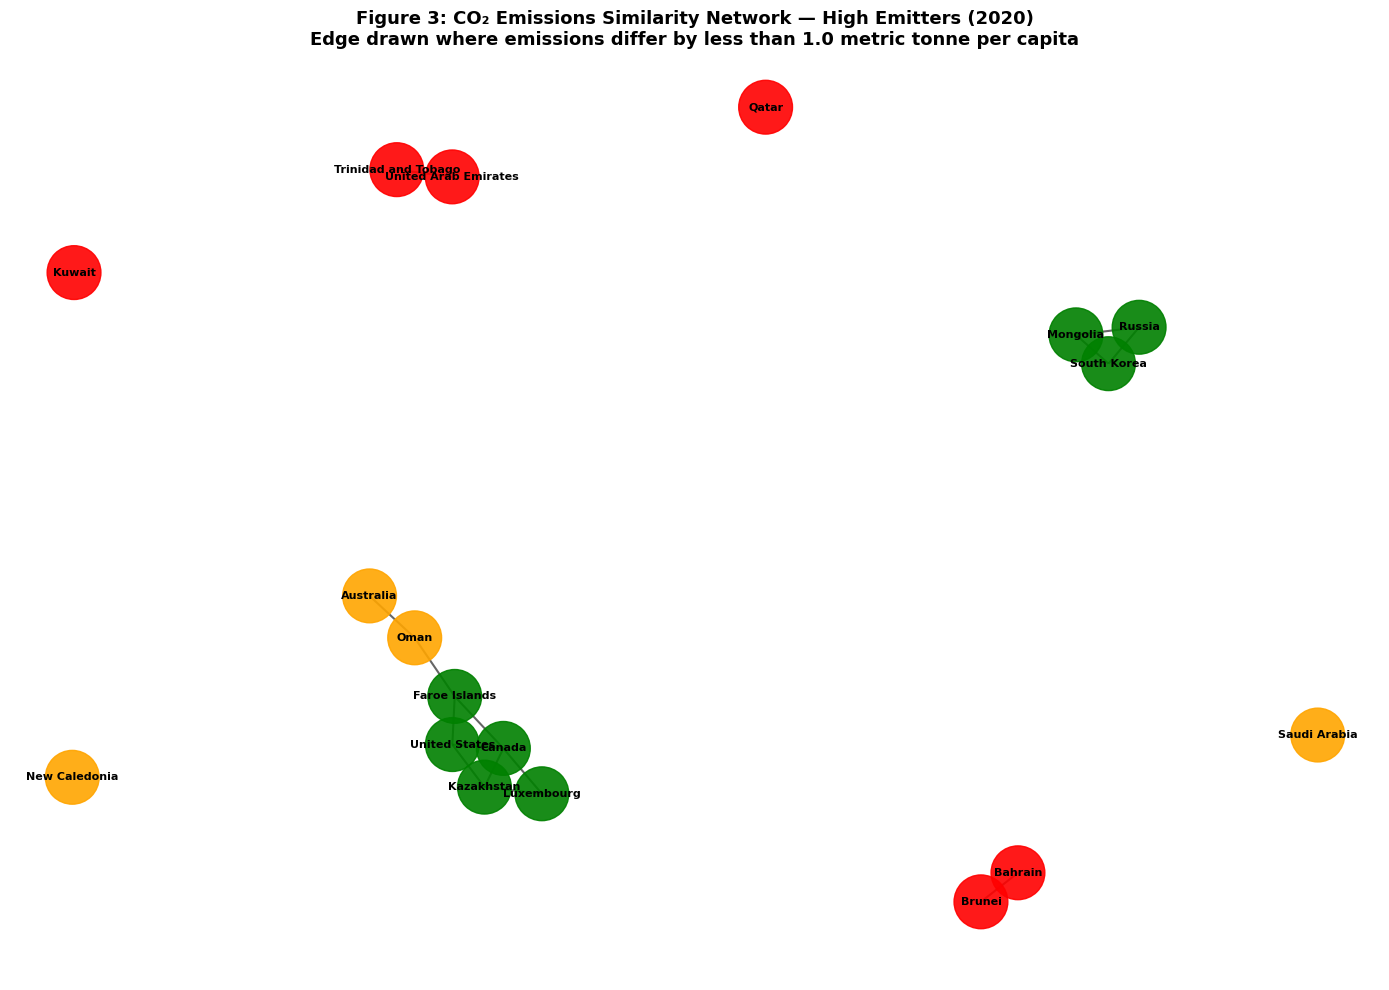

Number of nodes (countries): 18
Number of edges (similar pairs): 14
Isolated nodes (no similar peers): 4


In [17]:
#Step 6.3 Visualising the graph
fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42) #Spring layout naturally clusters similar emission countries together

#Colour coding the nodes to show the difference in their CO2 emissions
co2_values = [G.nodes[node]['co2'] for node in G.nodes]
node_colours = ['red' if G.nodes[node]['co2']> 20
                else 'orange' if G.nodes[node]['co2'] > 15
                else 'green'
                for node in G.nodes]

nx.draw_networkx_nodes(G, pos, node_color=node_colours, 
                       node_size=1500, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, 
                        font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='black', 
                       width=1.5, alpha=0.6, ax=ax)

ax.set_title('Figure 3: CO₂ Emissions Similarity Network — High Emitters (2020)\n'
             'Edge drawn where emissions differ by less than 1.0 metric tonne per capita',
             fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.axis('off')

plt.tight_layout()
plt.savefig('fig3_network_graph.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 6.3 Print basic graph statistics
print(f"Number of nodes (countries): {G.number_of_nodes()}")
print(f"Number of edges (similar pairs): {G.number_of_edges()}")
print(f"Isolated nodes (no similar peers): {len(list(nx.isolates(G)))}")

In [18]:
#Step 7 Aggregation & Visualisation
#Step 7.1 Line Chart - Average Global Temperature Anomaly Over Time
average_global_temp_by_year = cleaned_df.groupby('Year')['Annual Temperature Anomaly'].mean().reset_index()

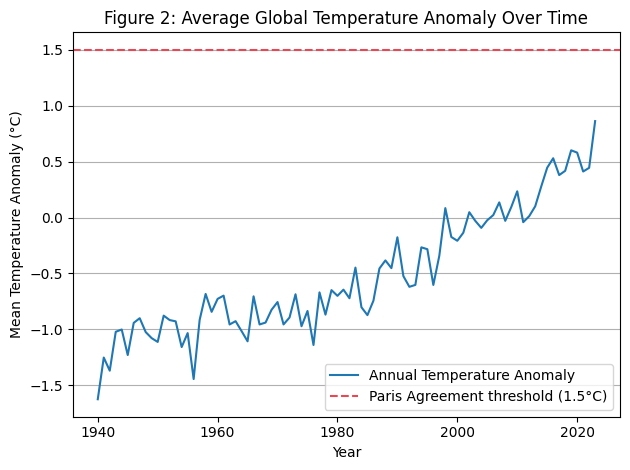

In [19]:
#Step 7.2 Line Chart of Average Temperature over Time
average_global_temp_by_year.set_index('Year')['Annual Temperature Anomaly'].plot(kind='line')
plt.title('Figure 2: Average Global Temperature Anomaly Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Temperature Anomaly (°C)')
plt.grid(axis='y')
plt.axhline(y=1.5, color='#E84855', linestyle='--', 
            linewidth=1.5, label='Paris Agreement threshold (1.5°C)')
plt.legend()
plt.tight_layout()
plt.savefig('fig2_line_temp_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Step 7.3 Creating variable that stores CO2 emissions for each country in 2020
# Reusing the same 10 metric tonne threshold established in Step 3 for consistency
country_co2_2020 = (
    cleaned_df[cleaned_df['Year'] == 2020]
    .groupby('Country Name')['CO2 Emissions Per Capita']
    .mean()  
    .sort_values(ascending=True)  # Ascending for horizontal readability
    .reset_index()
)

top_co2_2020 = country_co2_2020[country_co2_2020['CO2 Emissions Per Capita'] > 10]
print(top_co2_2020)

             Country Name  CO2 Emissions Per Capita
169                Russia                 11.156080
170              Mongolia                 11.265909
171           South Korea                 11.524341
172            Luxembourg                 12.806264
173            Kazakhstan                 13.113933
174                Canada                 13.795024
175         United States                 13.889589
176         Faroe Islands                 14.426020
177                  Oman                 15.174401
178             Australia                 15.506062
179         New Caledonia                 17.981370
180          Saudi Arabia                 19.879406
181                Kuwait                 21.739220
182  United Arab Emirates                 23.006842
183   Trinidad and Tobago                 23.677786
184                Brunei                 24.939121
185               Bahrain                 25.215979
186                 Qatar                 36.564110


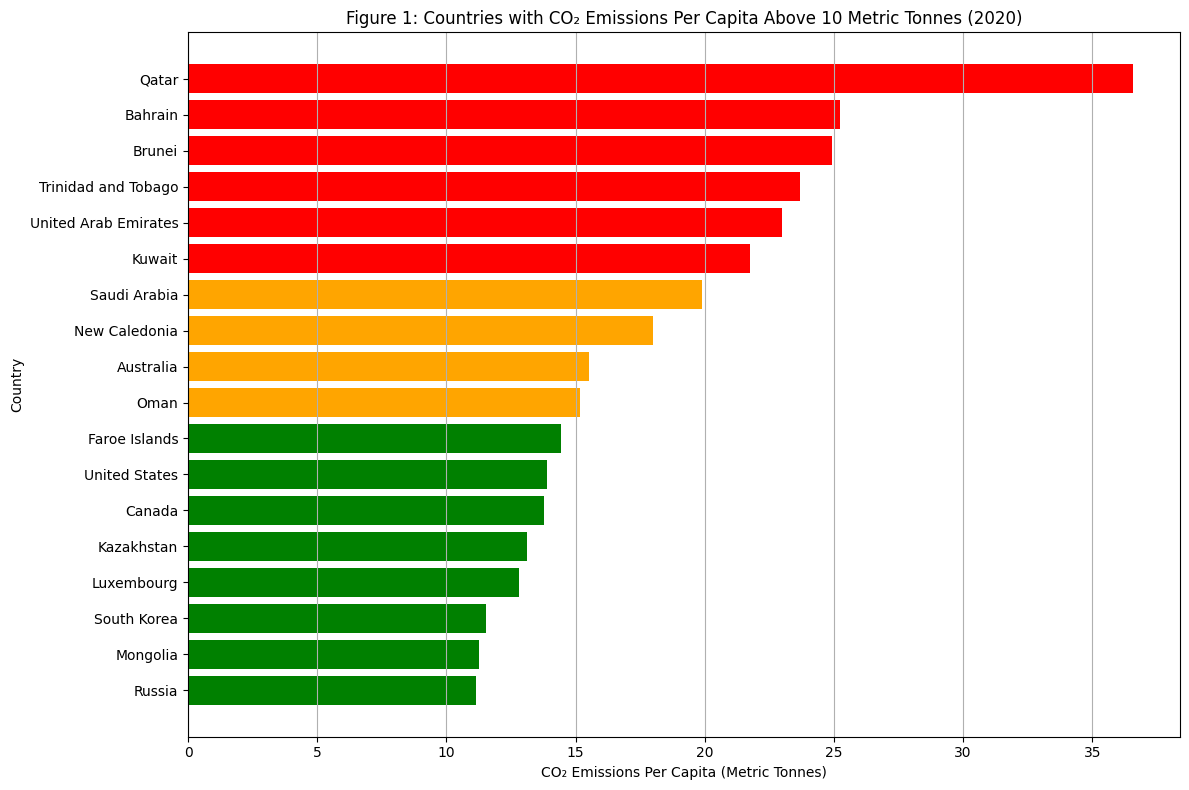

In [21]:
# Step 7.3.1 Creating the bar chart
# Colour coded to match network graph from Step 6 — red above 20t, orange 15-20t, blue 10-15t
colours = ['red' if v > 20 
           else 'orange' if v > 15 
           else 'green' 
           for v in top_co2_2020['CO2 Emissions Per Capita']]

plt.figure(figsize=(12, 8))
plt.barh(top_co2_2020['Country Name'], top_co2_2020['CO2 Emissions Per Capita'], color=colours)
plt.title('Figure 1: Countries with CO₂ Emissions Per Capita Above 10 Metric Tonnes (2020)')
plt.xlabel('CO₂ Emissions Per Capita (Metric Tonnes)')
plt.ylabel('Country')
plt.grid(axis='x')  # Gridlines on x axis to make values easier to read
plt.tight_layout()  # Adjust spacing so nothing gets cut off
plt.savefig('fig1_bar_co2_emitters.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
#Step 7.4  Filtering 2020 data for the 18 high emitting countries
# Reusing top_co2_2020 from Step 7.3 
temp_co2_2020 = cleaned_df[
    (cleaned_df['Year'] == 2020) &
    (cleaned_df['Country Name'].isin(top_co2_2020['Country Name']))
].reset_index(drop=True)
print(temp_co2_2020)

            Country Name  Year  CO2 Emissions Per Capita  \
0              Australia  2020                 15.506062   
1                Bahrain  2020                 25.215979   
2                 Brunei  2020                 24.939121   
3                 Canada  2020                 13.795024   
4          Faroe Islands  2020                 14.426020   
5             Kazakhstan  2020                 13.113933   
6                 Kuwait  2020                 21.739220   
7             Luxembourg  2020                 12.806264   
8               Mongolia  2020                 11.265909   
9          New Caledonia  2020                 17.981370   
10                  Oman  2020                 15.174401   
11                 Qatar  2020                 36.564110   
12                Russia  2020                 11.156080   
13          Saudi Arabia  2020                 19.879406   
14           South Korea  2020                 11.524341   
15   Trinidad and Tobago  2020          

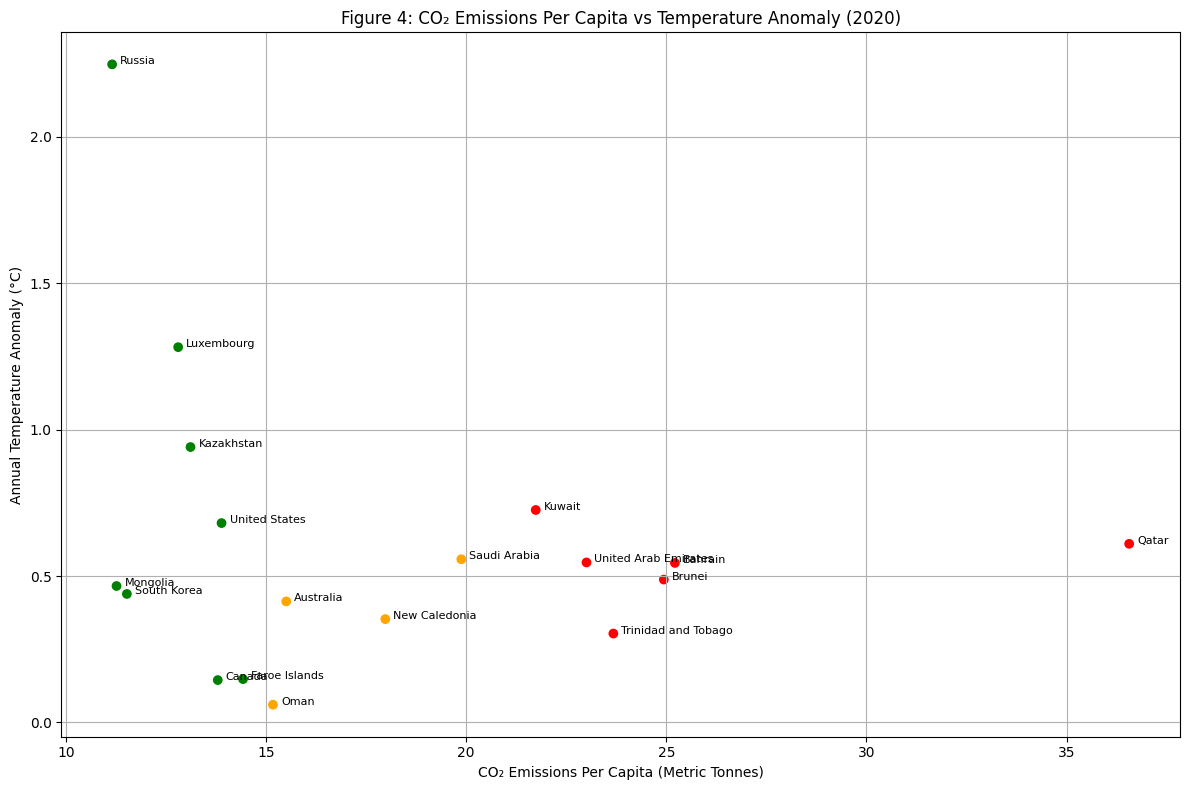

In [24]:
#Step 7.4.2 Scatterplot of CO2 vs Temperature Anomaly (2020)
colours = ['red' if v > 20
           else 'orange' if v > 15
           else 'green'
           for v in temp_co2_2020['CO2 Emissions Per Capita']]

plt.figure(figsize=(12, 8))
plt.scatter(temp_co2_2020['CO2 Emissions Per Capita'],
            temp_co2_2020['Annual Temperature Anomaly'],
            color=colours)

# Label each country point directly — consistent with network graph labels
for _, row in temp_co2_2020.iterrows():
    plt.text(row['CO2 Emissions Per Capita'] + 0.2,
             row['Annual Temperature Anomaly'],
             row['Country Name'], fontsize=8)

plt.title('Figure 4: CO₂ Emissions Per Capita vs Temperature Anomaly (2020)')
plt.xlabel('CO₂ Emissions Per Capita (Metric Tonnes)')
plt.ylabel('Annual Temperature Anomaly (°C)')
plt.grid(True)
plt.tight_layout()
plt.savefig('fig4_scatter_co2_temp.png', dpi=150, bbox_inches='tight')
plt.show()